In [1]:
# --- loader_agg_rs.py ---
from pathlib import Path
import json, math, re
from collections import defaultdict
from typing import Dict, Tuple, Any, List
import numpy as np

def _sem(arr: List[float]) -> float:
    """Standard error of the mean (unbiased, ddof=1), ignoring non-finite values."""
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]
    n = a.size
    if n <= 1:
        return float('nan')
    return float(a.std(ddof=1) / math.sqrt(n))

def _safe_float(x, default=float('nan')) -> float:
    try:
        xf = float(x)
        return xf
    except Exception:
        return default

def _parse_P_kappa_from_filename(name: str) -> Tuple[int, float]:
    """
    Extract P and kappa from filenames like:
      rs_aw_..._P10000_kap1.000e-01_..._Ptr10000_..._kap7.500e-02_...
    Priority:
      1) Ptr{P}
      2) first standalone _P{int}_ (not Peval)
      3) first kap{number}
    """
    P = None
    m_ptr = re.search(r'Ptr(\d+)', name)
    if m_ptr:
        P = int(m_ptr.group(1))
    else:
        m_p = re.search(r'(?<!Peval)(?:^|_)P(\d+)(?=_)', name)
        if m_p:
            P = int(m_p.group(1))

    kappa = float('nan')
    m_k = re.search(r'kap([+\-]?\d*\.?\d+(?:[eE][+\-]?\d+)?)', name)
    if m_k:
        kappa = _safe_float(m_k.group(1))
    return P, kappa

def _last_of(x):
    if isinstance(x, list) and x:
        return x[-1]
    return x

def _final_test_halfmse_from_traj(traj: dict) -> float:
    """
    Prefer traj['half_mse_empirical'][-1] (this is 1/2 · test MSE on held-out).
    Fallbacks: half_mse_total_ms, mean(last half_mse_empirical_per_exp), finally 0.5 * last train_mse.
    Returns HALF-MSE units.
    """
    v = _last_of(traj.get('half_mse_empirical'))
    if isinstance(v, (float, int)):
        return float(v)

    v = _last_of(traj.get('half_mse_total_ms'))
    if isinstance(v, (float, int)):
        return float(v)

    per_exp = traj.get('half_mse_empirical_per_exp')
    if isinstance(per_exp, list) and per_exp:
        last = per_exp[-1]
        try:
            arr = np.asarray(last, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size:
                return float(np.mean(arr))
        except Exception:
            pass

    tm = _last_of(traj.get('train_mse'))
    if isinstance(tm, (float, int)):
        return 0.5 * float(tm)

    return float('nan')

def _final_train_mse_from_traj(traj: dict) -> float:
    """Return last logged train_mse (FULL MSE units), or NaN if missing."""
    tm = _last_of(traj.get('train_mse'))
    if isinstance(tm, (float, int)):
        return float(tm)
    return float('nan')

def aggregate_rs_results_by_P_kappa(
    root_dir: str,
    filename_glob: str = "**/*.json",
    *,
    fill_invalid_with_one: bool = False,   # keep False for correct SEM; True mimics old behavior
) -> Dict[Tuple[int, float], Dict[str, Any]]:
    """
    Walks `root_dir` recursively, loads run JSONs from the RS cavity script,
    aggregates by (P, kappa). Produces both TEST and TRAIN MSE stats with correct SEM.
    - TEST values are taken from 'half_mse_empirical' (converted to FULL MSE).
    - TRAIN values are taken from 'train_mse' (already FULL MSE).

    Keys in each bucket:
      mean_test_mse, sem_test_mse, n_test
      mean_train_mse, sem_train_mse, n_train
      mean_test_halfmse, sem_test_halfmse       # for convenience (half units)
      mean_train_halfmse, sem_train_halfmse     # for convenience (half units)
      mean_mS_final, sem_mS_final               # if present
      P, kappa
    """
    root = Path(root_dir)
    files = list(root.glob(filename_glob))

    buckets = defaultdict(lambda: {
        "test_halfmse": [],   # per-run half·MSE
        "train_mse": [],      # per-run full MSE
        "mS": []              # optional
    })

    for fp in files:
        if not fp.name.endswith(".json"):
            continue
        try:
            with open(fp, "r") as f:
                payload = json.load(f)
        except Exception:
            continue

        traj = payload.get("traj", {})
        cfg = payload.get("config", {})

        kappa_cfg = _safe_float(cfg.get("kappa"))
        P_name, kappa_name = _parse_P_kappa_from_filename(fp.name)
        P = P_name
        kappa = kappa_cfg if (not math.isnan(kappa_cfg)) else kappa_name
        if P is None or (kappa is None) or math.isnan(float(kappa)):
            continue

        test_half = _final_test_halfmse_from_traj(traj)   # half units
        train_full = _final_train_mse_from_traj(traj)     # full units

        # optional m_S (final scalar average across modes)
        mS_hist = traj.get("m_S")
        if isinstance(mS_hist, list) and mS_hist:
            last = mS_hist[-1]
            try:
                arr = np.asarray(last, dtype=float)
                # If it's a list of per-mode values, average them; else cast to float
                mS_val = float(np.mean(arr)) if arr.size else float('nan')
            except Exception:
                try:
                    mS_val = float(last)
                except Exception:
                    mS_val = float('nan')
        else:
            mS_val = float('nan')

        key = (int(P), float(kappa))
        if np.isfinite(test_half):
            buckets[key]["test_halfmse"].append(float(test_half))
        if np.isfinite(train_full):
            buckets[key]["train_mse"].append(float(train_full))
        if np.isfinite(mS_val):
            buckets[key]["mS"].append(float(mS_val))

    out: Dict[Tuple[int, float], Dict[str, Any]] = {}
    for (P, kappa), vals in buckets.items():
        test_half_arr = [v for v in vals["test_halfmse"] if np.isfinite(v)]
        train_full_arr = [v for v in vals["train_mse"] if np.isfinite(v)]
        mS_arr = [v for v in vals["mS"] if np.isfinite(v)]

        # Compute means/SEMs (ignoring non-finite)
        mean_test_half = float(np.mean(test_half_arr)) if test_half_arr else float('nan')
        sem_test_half  = _sem(test_half_arr) if test_half_arr else float('nan')
        mean_test_full = (2.0 * mean_test_half) if np.isfinite(mean_test_half) else float('nan')
        sem_test_full  = (2.0 * sem_test_half) if np.isfinite(sem_test_half) else float('nan')

        mean_train_full = float(np.mean(train_full_arr)) if train_full_arr else float('nan')
        sem_train_full  = _sem(train_full_arr) if train_full_arr else float('nan')
        mean_train_half = (0.5 * mean_train_full) if np.isfinite(mean_train_full) else float('nan')
        sem_train_half  = (0.5 * sem_train_full) if np.isfinite(sem_train_full) else float('nan')

        mean_mS = float(np.mean(mS_arr)) if mS_arr else float('nan')
        sem_mS  = _sem(mS_arr) if mS_arr else float('nan')

        if fill_invalid_with_one:
            def _fi(x): 
                try:
                    xf = float(x)
                    return 1.0 if (not np.isfinite(xf)) else xf
                except Exception:
                    return 1.0
            mean_test_full = _fi(mean_test_full); sem_test_full = _fi(sem_test_full)
            mean_train_full = _fi(mean_train_full); sem_train_full = _fi(sem_train_full)
            mean_test_half = _fi(mean_test_half); sem_test_half = _fi(sem_test_half)
            mean_train_half = _fi(mean_train_half); sem_train_half = _fi(sem_train_half)
            mean_mS = _fi(mean_mS); sem_mS = _fi(sem_mS)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,

            # --- TEST (FULL MSE) ---
            "mean_test_mse": mean_test_full,
            "sem_test_mse": sem_test_full,
            "n_test": len(test_half_arr),

            # --- TRAIN (FULL MSE) ---
            "mean_train_mse": mean_train_full,
            "sem_train_mse": sem_train_full,
            "n_train": len(train_full_arr),

            # --- (Convenience) HALF units ---
            "mean_test_halfmse": mean_test_half,
            "sem_test_halfmse": sem_test_half,
            "mean_train_halfmse": mean_train_half,
            "sem_train_halfmse": sem_train_half,

            # --- m_S, if present ---
            "mean_mS_final": mean_mS,
            "sem_mS_final": sem_mS,
        }

    return out

# --- Example usage ---
if __name__ == "__main__":
    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final2/ard_100_inner50_k2",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )
    from pprint import pprint
    pprint(results)


{(10, 0.005): {'P': 10,
               'kappa': 0.005,
               'mean_mS_final': 3.7050706547840186e-05,
               'mean_test_halfmse': 0.8321137463426567,
               'mean_test_mse': 1.6642274926853133,
               'mean_train_halfmse': 0.00019820602028630674,
               'mean_train_mse': 0.0003964120405726135,
               'n_test': 1,
               'n_train': 1,
               'sem_mS_final': nan,
               'sem_test_halfmse': nan,
               'sem_test_mse': nan,
               'sem_train_halfmse': nan,
               'sem_train_mse': nan},
 (500, 0.005): {'P': 500,
                'kappa': 0.005,
                'mean_mS_final': 0.0776795248190562,
                'mean_test_halfmse': 0.5737064778804779,
                'mean_test_mse': 1.1474129557609558,
                'mean_train_halfmse': 0.08679556101560593,
                'mean_train_mse': 0.17359112203121185,
                'n_test': 1,
                'n_train': 1,
                'sem_m

In [2]:
# --- plot_heatmaps_side_by_side.py ---
from pathlib import Path
import sys, math
from typing import Optional, Tuple, Sequence, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

PLOT_UTILS_DIR = "/home/goring/mean_field_langevin/plots_utils"  # where slim_plotters.py lives

def _apply_slim_style(theme: str = "light", serif: bool = True) -> None:
    try:
        if PLOT_UTILS_DIR not in sys.path:
            sys.path.insert(0, PLOT_UTILS_DIR)
        from slim_plotters import apply  # type: ignore
        apply(theme=theme, serif=serif)
    except Exception as e:
        print(f"[note] slim_plotters not applied ({e}); using Matplotlib defaults.)")

def _edges_from_centers(centers: np.ndarray, log: bool = False) -> np.ndarray:
    centers = np.asarray(centers, dtype=float)
    centers = np.sort(centers)
    n = centers.size
    if n == 1:
        c = centers[0]
        if log and c > 0:
            return np.array([c/np.sqrt(10.0), c*np.sqrt(10.0)])
        delta = 0.5 if c == 0 else 0.5 * abs(c)
        return np.array([c - delta, c + delta])

    if log and np.any(centers <= 0):
        log = False

    edges = np.empty(n + 1, dtype=float)
    if log:
        mids = np.sqrt(centers[:-1] * centers[1:])
        edges[1:-1] = mids
        r0 = centers[1] / centers[0]
        r1 = centers[-1] / centers[-2]
        edges[0] = centers[0] / np.sqrt(r0)
        edges[-1] = centers[-1] * np.sqrt(r1)
    else:
        mids = 0.5 * (centers[:-1] + centers[1:])
        edges[1:-1] = mids
        edges[0]  = centers[0] - (mids[0] - centers[0])
        edges[-1] = centers[-1] + (centers[-1] - mids[-1])
    return edges

def heatmap_from_agg_dict(
    agg_dict: Dict[Any, Dict[str, Any]],
    *,
    value_key: str = "mean_test_mse",
    cmap: str = "viridis",
    figsize: Tuple[float, float] = (4.0, 3.0),
    aspect: str = "auto",
    xlog: bool = False,
    ylog: bool = False,
    clog: bool = False,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    clabel: Optional[str] = None,
    sort_P_ascending: bool = True,
    sort_kappa_ascending: bool = True,
    xticks: Optional[Sequence[float]] = None,
    yticks: Optional[Sequence[float]] = None,
    xtick_labels: Optional[Sequence[str]] = None,
    ytick_labels: Optional[Sequence[str]] = None,
    save_path: Optional[str] = None,
    theme: str = "light",
    serif: bool = True,
    ax: Optional[plt.Axes] = None,          # NEW: draw into existing axis if provided
    norm: Optional[Normalize] = None,       # NEW: shared color normalization if provided
    show_colorbar: bool = True,             # NEW: let caller manage shared cbar
):
    """
    Build a heatmap from an aggregated dict. X = kappa, Y = P, cell = agg[value_key].
    If ax is provided, draws there; otherwise creates a new figure.
    If norm is provided, uses it and ignores (clog, vmin, vmax).
    """
    if ax is None:
        _apply_slim_style(theme=theme, serif=serif)
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # Collect (P, kappa, value)
    records = []
    for k, v in agg_dict.items():
        if isinstance(k, tuple) and len(k) == 2:
            P, kappa = k
        else:
            P = v.get("P")
            kappa = v.get("kappa")
        if P is None or kappa is None or value_key not in v:
            continue
        try:
            P = int(P); kappa = float(kappa); val = float(v[value_key])
        except (TypeError, ValueError):
            continue
        if math.isnan(val):
            continue
        records.append((P, kappa, val))
    if not records:
        raise ValueError(f"No usable entries for value_key='{value_key}'.")

    # Unique sorted axes
    Ps = sorted({r[0] for r in records}, reverse=not sort_P_ascending)
    kappas = sorted({r[1] for r in records}, reverse=not sort_kappa_ascending)

    # Build Z with running means in case of duplicates
    Z = np.full((len(Ps), len(kappas)), np.nan, dtype=float)
    counts = np.zeros_like(Z, dtype=int)
    p_index = {p: i for i, p in enumerate(Ps)}
    k_index = {k0: j for j, k0 in enumerate(kappas)}
    for P, k0, val in records:
        i = p_index[P]; j = k_index[k0]
        if np.isnan(Z[i, j]):
            Z[i, j] = val; counts[i, j] = 1
        else:
            Z[i, j] = (Z[i, j] * counts[i, j] + val) / (counts[i, j] + 1)
            counts[i, j] += 1

    # Axis centers and edges
    xcenters = np.asarray(kappas, dtype=float)
    ycenters = np.asarray(Ps, dtype=float)
    xedges = _edges_from_centers(xcenters, log=xlog)
    yedges = _edges_from_centers(ycenters, log=ylog)

    # Color normalization
    Zmask = np.ma.masked_invalid(Z)
    if norm is None:
        if clog:
            if vmin is not None and vmin <= 0:
                raise ValueError("For clog=True, vmin must be > 0.")
            if vmin is None:
                positive = np.asarray(Zmask.compressed())
                positive = positive[positive > 0]
                if positive.size == 0:
                    raise ValueError("clog=True but all values are <= 0 or NaN.")
                vmin_use = float(positive.min())
            else:
                vmin_use = float(vmin)
            vmax_use = float(np.nanmax(Z)) if vmax is None else float(vmax)
            norm = LogNorm(vmin=vmin_use, vmax=vmax_use)
        else:
            norm = Normalize(vmin=vmin, vmax=vmax)

    # Draw
    mesh = ax.pcolormesh(xedges, yedges, Zmask, cmap=cmap, norm=norm, shading="auto")
    if show_colorbar:
        cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(clabel if clabel is not None else value_key, labelpad=4)

    # Axes config
    if xlog: ax.set_xscale("log")
    if ylog: ax.set_yscale("log")
    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel("P")
    ax.set_aspect(aspect)
    ax.grid(False)

    # Ticks
    def _fmt_kappa(x: float) -> str:
        return f"{x:.2g}" if (abs(x) < 1e-2 or abs(x) >= 1e2) else f"{x:g}"

    if xticks is None:
        xt = xcenters
        xlabels = [_fmt_kappa(x) for x in xcenters]
    else:
        xt = np.asarray(list(xticks), dtype=float)
        if xlog:
            xt = xt[xt > 0]
        xlabels = list(xtick_labels) if xtick_labels is not None else [_fmt_kappa(x) for x in xt]
    ax.set_xticks(xt)
    ax.set_xticklabels(xlabels)

    if yticks is None:
        yt = ycenters
        ylabels = [str(int(y)) for y in ycenters]
    else:
        yt = np.asarray(list(yticks), dtype=float)
        if ylog:
            yt = yt[yt > 0]
        ylabels = list(ytick_labels) if ytick_labels is not None else [str(int(y)) for y in yt]
    ax.set_yticks(yt)
    ax.set_yticklabels(ylabels)

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[saved] {save_path}")

    return fig, ax, {"Z": Z, "Ps": Ps, "kappas": kappas, "counts": counts, "norm": norm}

# --- Example: side-by-side TEST vs TRAIN (shared color scale) ---


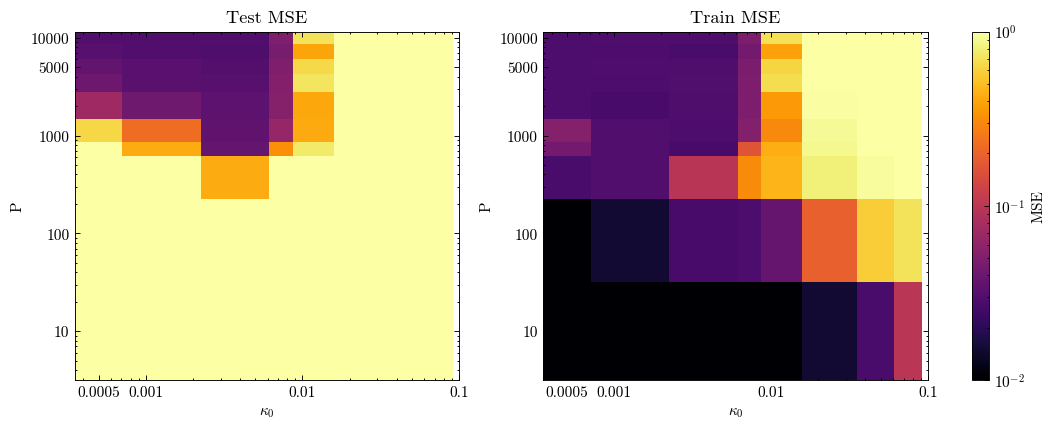

In [5]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_12.0gd_linear",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()


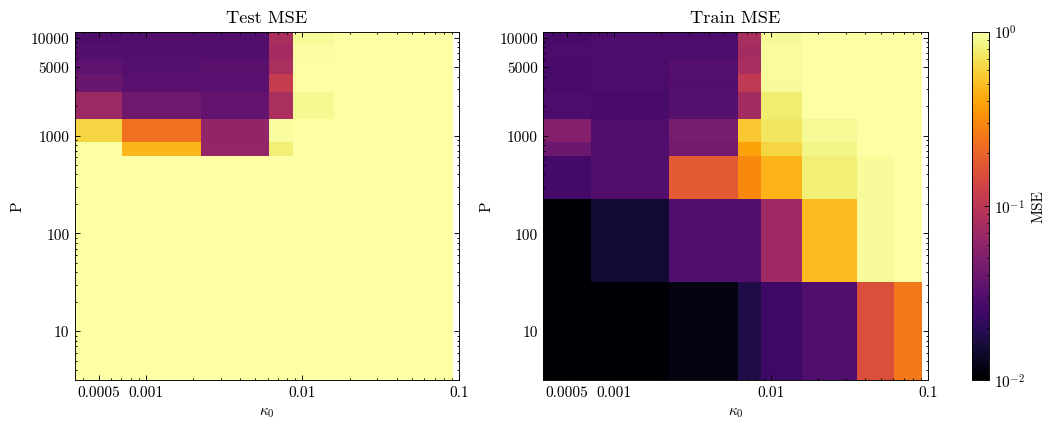

In [6]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_5.0gd_nolinear",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()




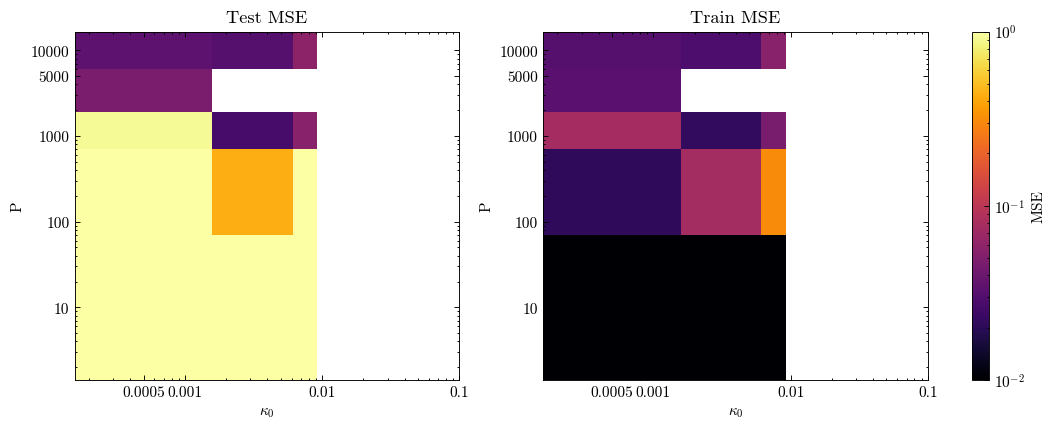

In [11]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final4",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()




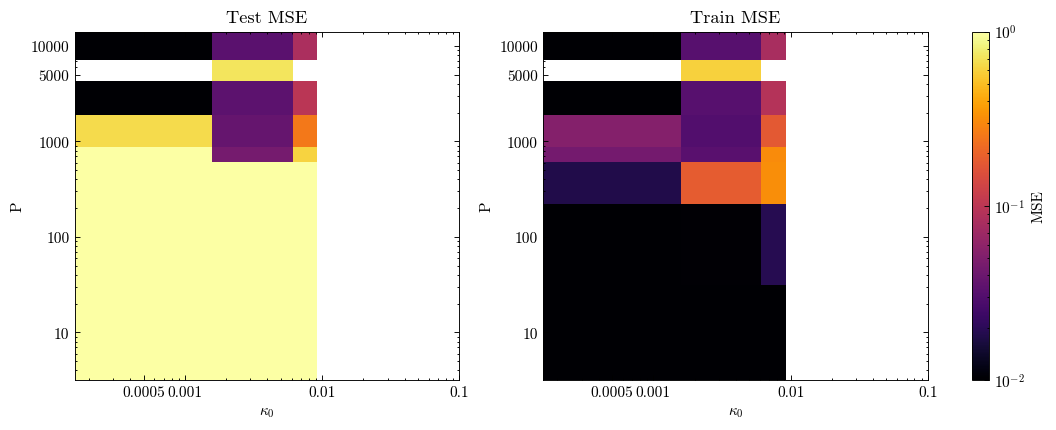

In [22]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final5",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()




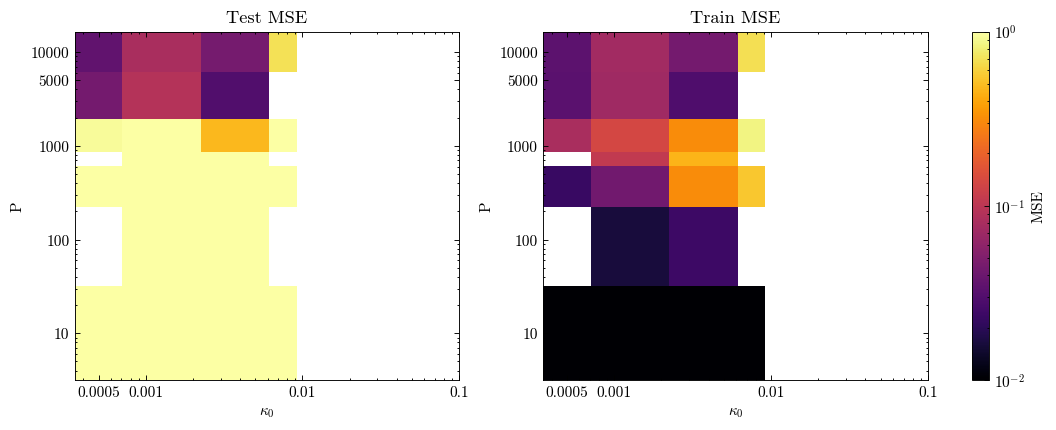

In [66]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()




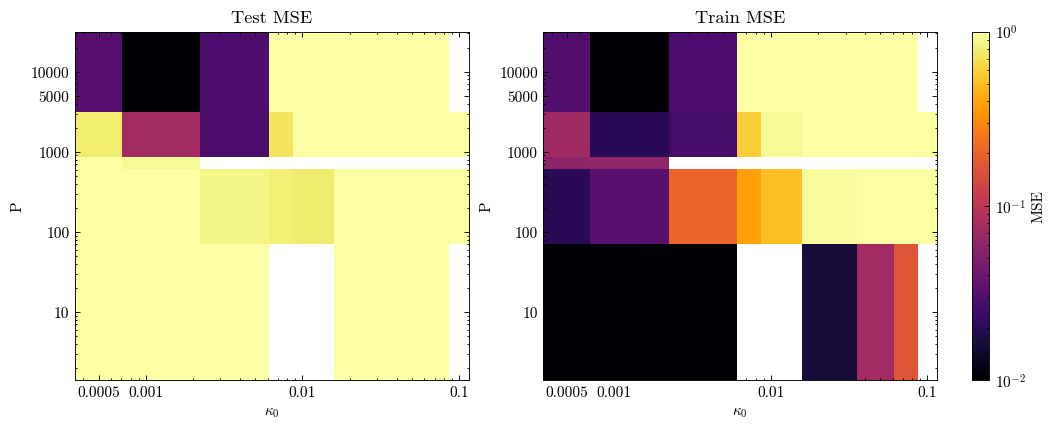

In [6]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()




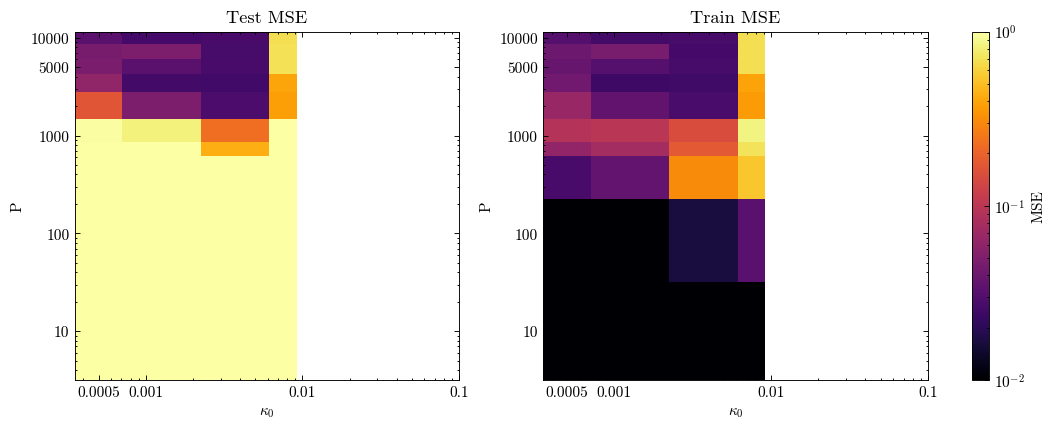

In [36]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long3",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()




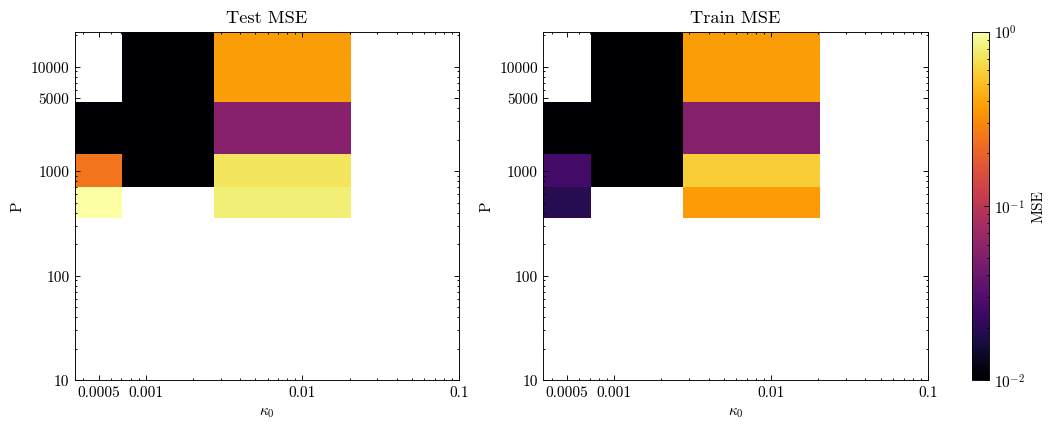

In [3]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()




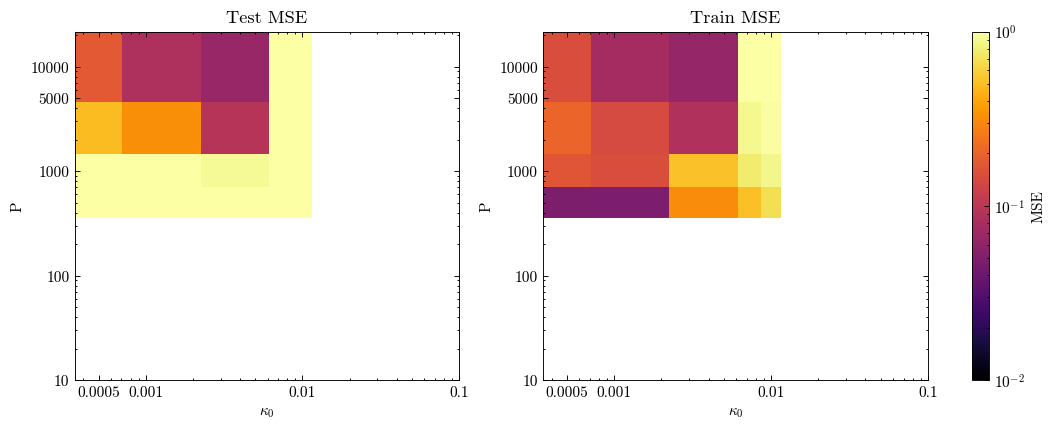

In [17]:
if __name__ == "__main__":
    #from loader_agg_rs import aggregate_rs_results_by_P_kappa

    results = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard0.5",
        filename_glob="**/*.json",
        fill_invalid_with_one=False,
    )

    # Choose a shared LogNorm (or set to None to auto-fit each panel separately)
    shared_norm = LogNorm(vmin=1e-2, vmax=1)  # adjust to your range

    _apply_slim_style(theme="light", serif=True)
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)

    # Left: TEST MSE
    _, axL, _ = heatmap_from_agg_dict(
        results,
        value_key="mean_test_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Test MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[0],
        norm=shared_norm,
        show_colorbar=False,  # one shared colorbar on the right
    )
    axes[0].set_title("Test MSE")

    # Right: TRAIN MSE
    _, axR, metaR = heatmap_from_agg_dict(
        results,
        value_key="mean_train_mse",
        cmap="inferno",
        aspect="auto",
        xlog=True, ylog=True,
        clabel="Mean Train MSE",
        xticks=[5e-4, 1e-3, 1e-2, 1e-1],
        yticks=[10, 100, 1000, 5000, 10000],
        ax=axes[1],
        norm=shared_norm,
        show_colorbar=False,
    )
    axes[1].set_title("Train MSE")

    # One shared colorbar for both panels
    # Use the last mesh's norm (shared_norm) and cmap
    sm = plt.cm.ScalarMappable(norm=shared_norm, cmap="inferno")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    cbar.set_label("MSE")

    plt.show()


